ЛАБОРАТОРНАЯ РАБОТА ПО ОБРАБОТКЕ ИЗОБРАЖЕНИЙ #10
 
1. Текстурные характеристики: реализуйте подсчет гистограммы 
--------------------------------------------------------------------------------


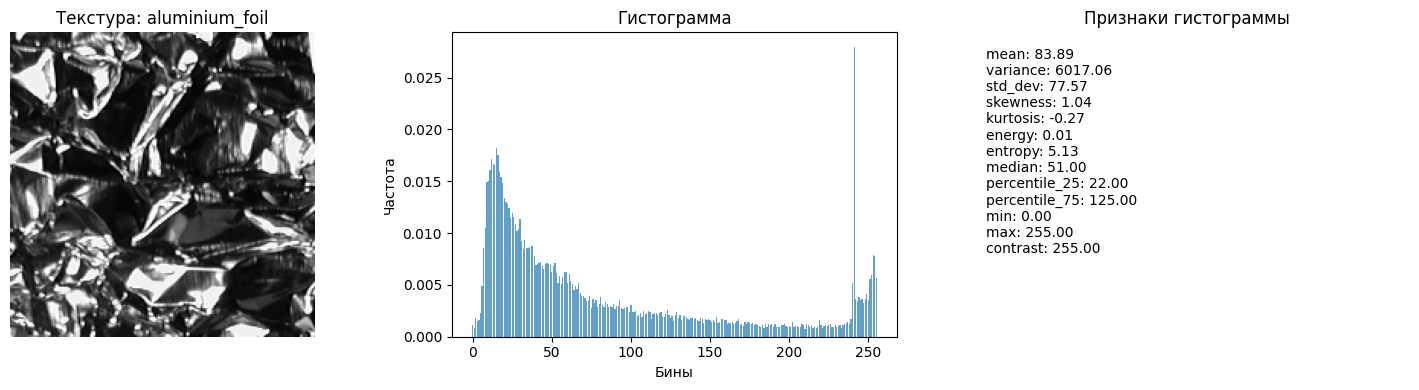

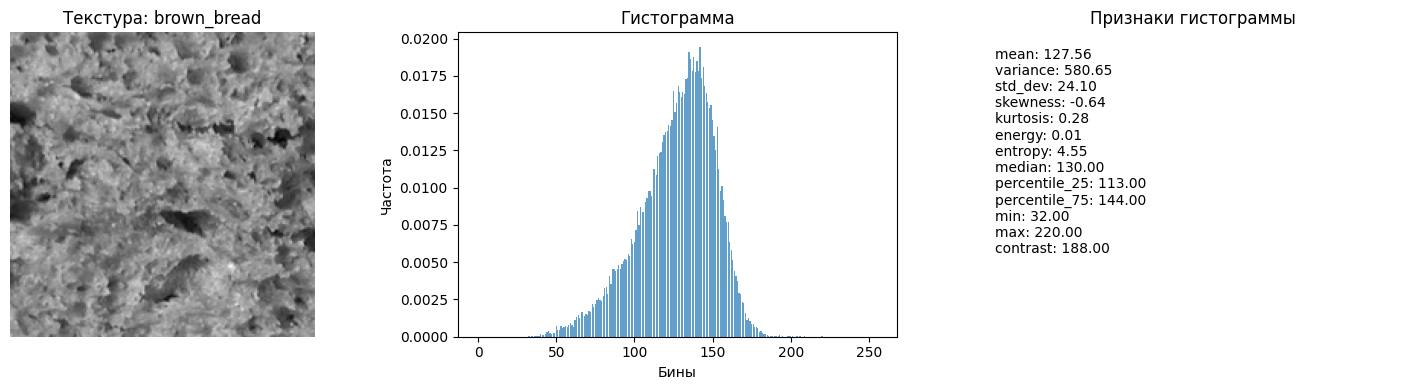

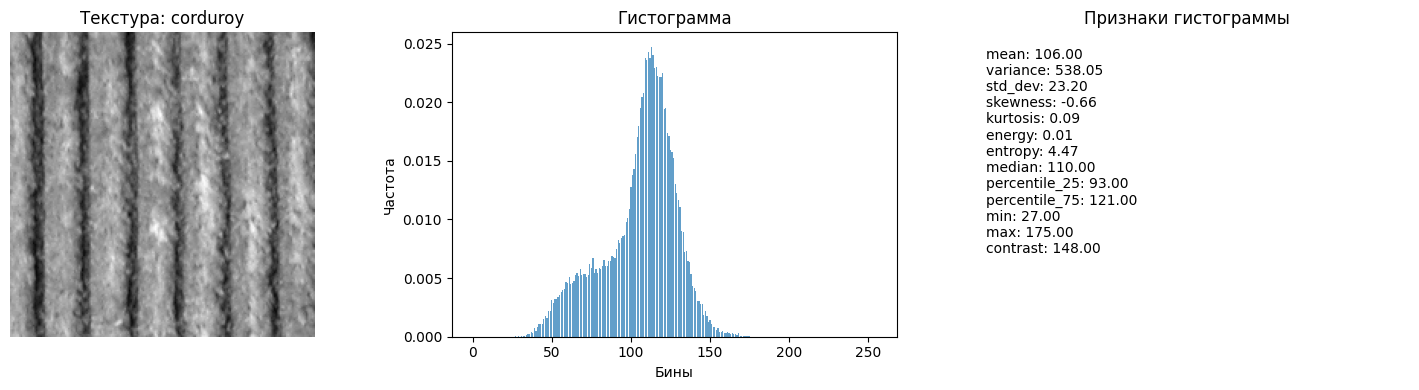

Гистограммные признаки вычислены



2. Текстурные характеристики: реализуйте расчет текстурных характеристик Laws
--------------------------------------------------------------------------------
Демонстрация работы Laws фильтров:



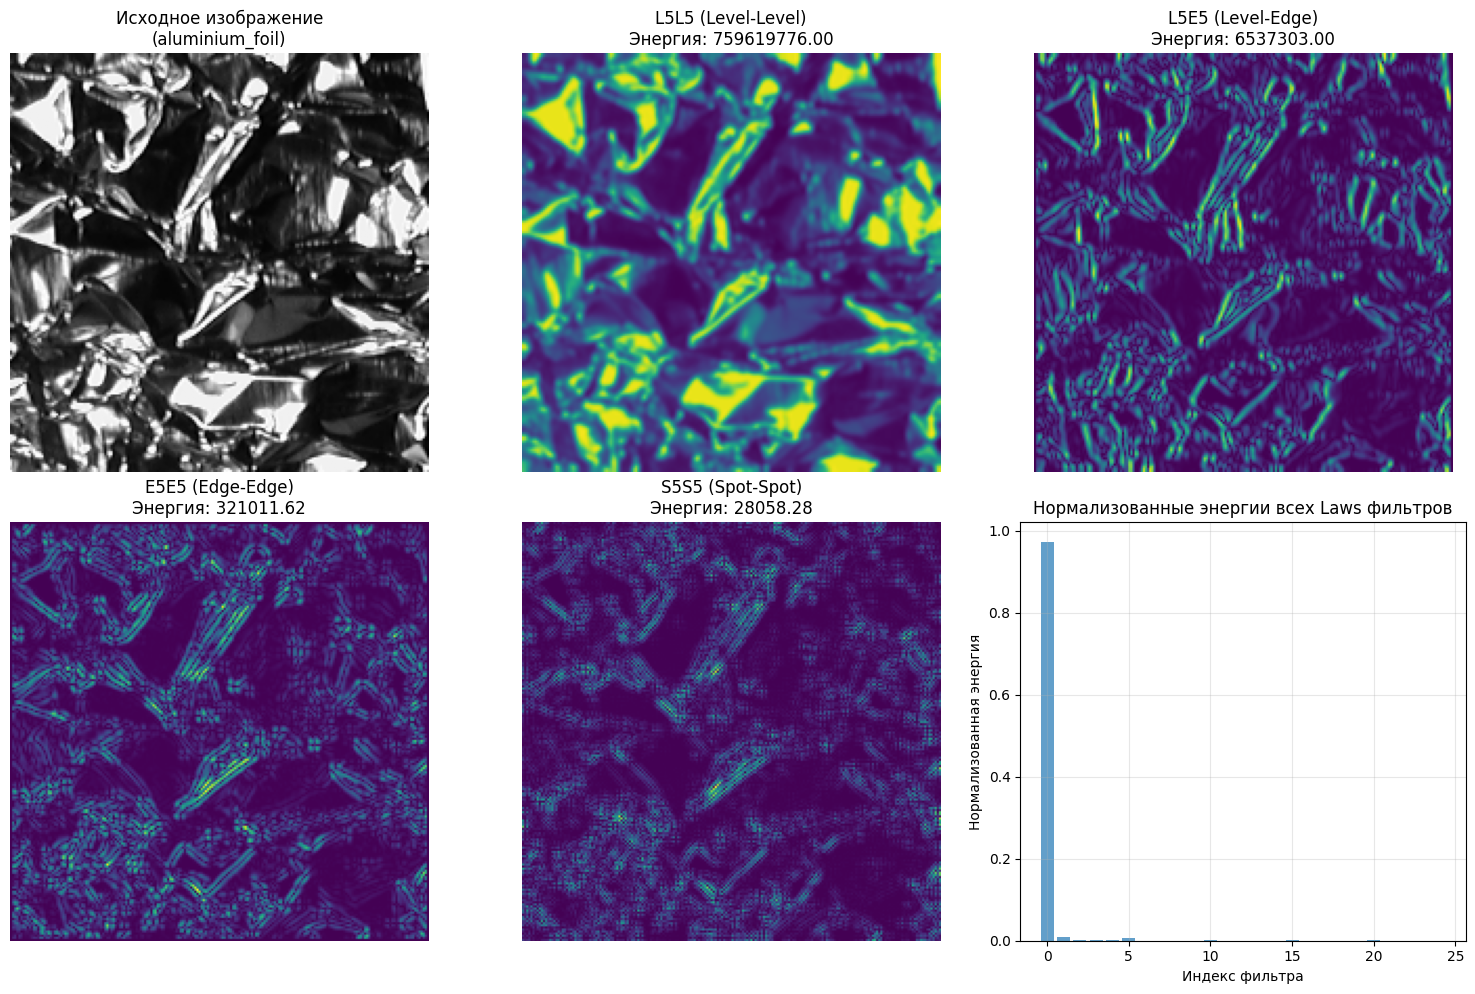

Извлечено 25 признаков Laws
Примеры признаков:
  L5L5: 0.972662
  L5E5: 0.008371
  L5S5: 0.001670
  L5W5: 0.001084
  L5R5: 0.002572
  ... и ещё 20 признаков

Текстурные характеристики Laws реализованы и визуализированы



3. Текстурные характеристики: реализуйте расчет текстурных характеристик на основе матрицы GLCM
--------------------------------------------------------------------------------


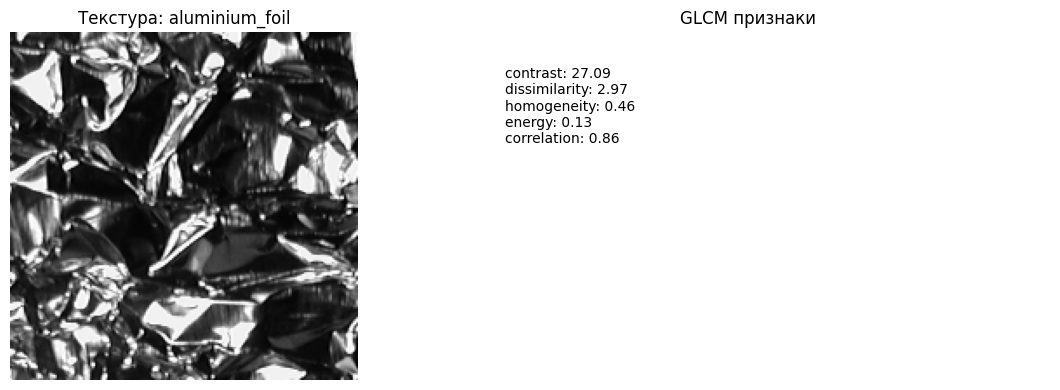

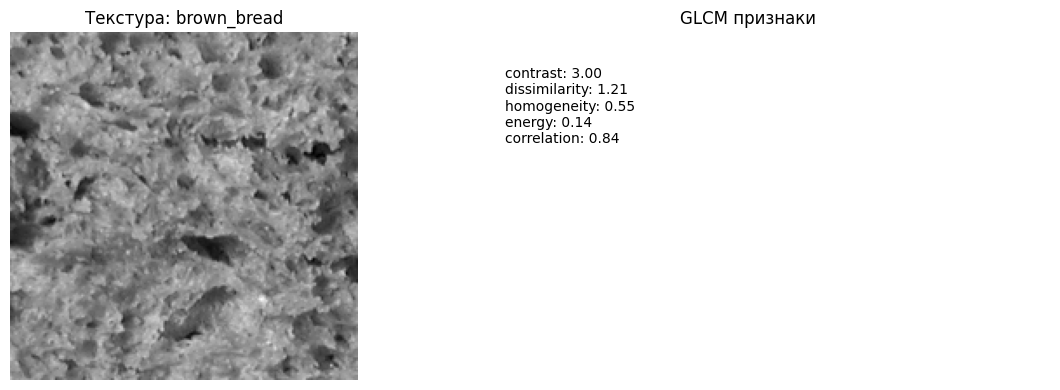

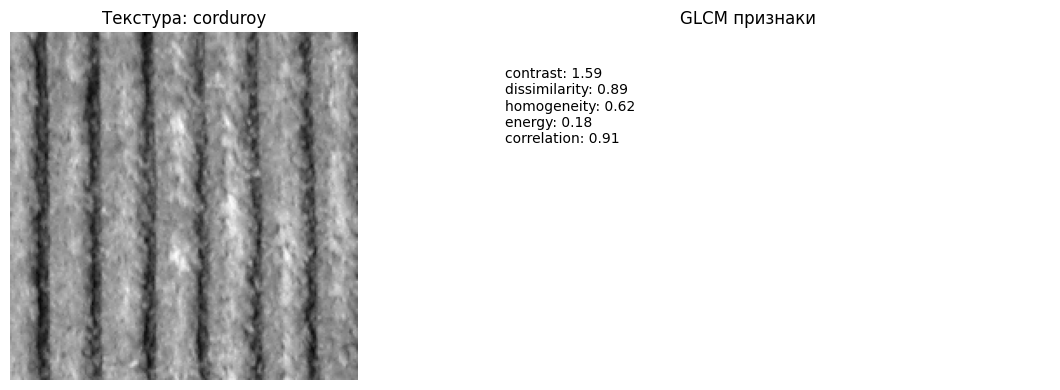

GLCM признаки вычислены



4. Обучение классификаторов (KNN, SVM, DecisionTree)
--------------------------------------------------------------------------------
Тренировка моделей для признаков: Histogram
  Размер данных: (500, 13)
  KNN             | Accuracy=0.872 | F1-score=0.875
  SVM             | Accuracy=0.760 | F1-score=0.760
  DecisionTree    | Accuracy=0.744 | F1-score=0.743

Тренировка моделей для признаков: Laws
  Размер данных: (500, 25)
  KNN             | Accuracy=0.824 | F1-score=0.826
  SVM             | Accuracy=0.536 | F1-score=0.520
  DecisionTree    | Accuracy=0.688 | F1-score=0.687

Тренировка моделей для признаков: GLCM
  Размер данных: (500, 5)
  KNN             | Accuracy=0.704 | F1-score=0.704
  SVM             | Accuracy=0.544 | F1-score=0.546
  DecisionTree    | Accuracy=0.624 | F1-score=0.630

Все модели обучены



5. Решение задачи сегментации на основе классификации
--------------------------------------------------------------------------------
Сегментац

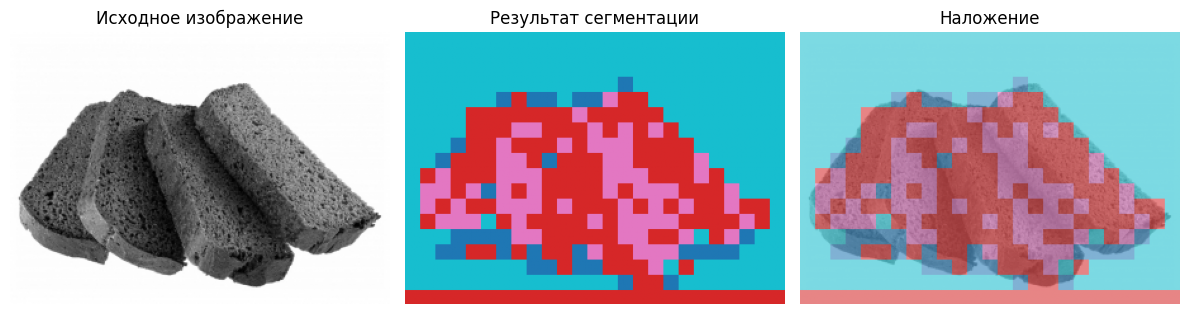

Сегментация методом GLCM + DecisionTree:


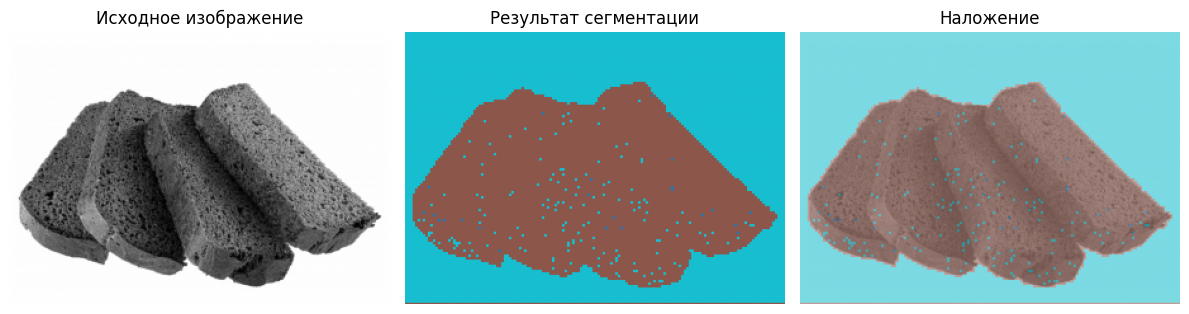




6. Выполнение ручной разметки изображения на регионы
--------------------------------------------------------------------------------


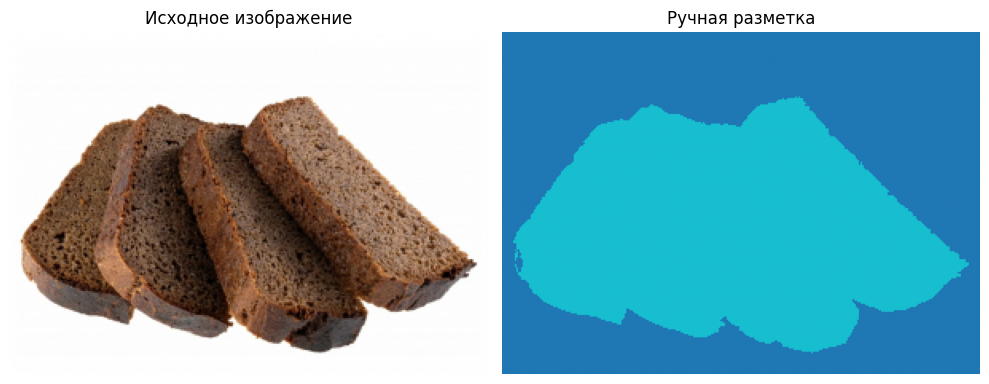

Ручная разметка выполнена



7. Сравнение результата классификации и ручной разметки
--------------------------------------------------------------------------------
Сравнение для метода: GLCM + DecisionTree

Точность (Accuracy): 96.7%
IoU по классам:
  Класс 0: 0.939
  Класс 1: 0.931


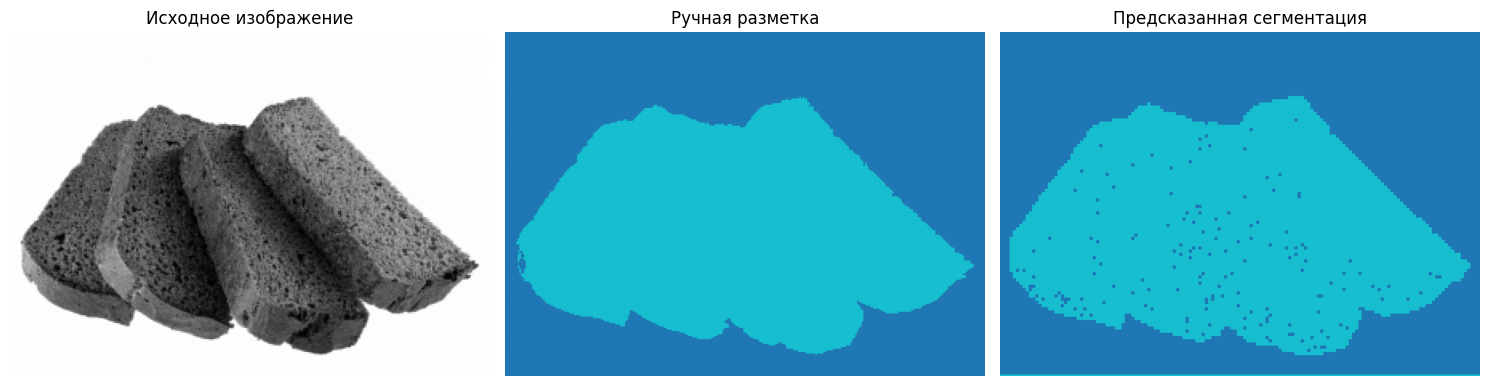

In [6]:
import os
import warnings
import cv2
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import skew, kurtosis, entropy
from skimage.feature import graycomatrix, graycoprops
from sklearn.metrics import classification_report, accuracy_score, jaccard_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

print("="*50)
print("ЛАБОРАТОРНАЯ РАБОТА ПО ОБРАБОТКЕ ИЗОБРАЖЕНИЙ #10")
print("="*50)
print(" ")

IMAGE_FOLDER = "kth_tips_grey_200x200/KTH_TIPS"
TEST_IMAGE = "bread.jpeg"

###1 ЗАДАНИЕ: Текстурные характеристики: реализуйте подсчет гистограммы
print("1. Текстурные характеристики: реализуйте подсчет гистограммы ")
print("-"*80)

def count_histogram_features(img, bins_num):     #Вычисление признаков на основе гистограммы изображения
    hist = cv2.calcHist([img], [0], None, [bins_num], [0, 256])
    hist = hist.flatten()

    bin_width = 256 / bins_num
    bin_centers = np.array([i * bin_width + bin_width / 2 for i in range(bins_num)])
    hist_normalized = hist / np.sum(hist)

    weighted_data = np.repeat(bin_centers, hist.astype(int))

    features = {
        'mean': np.average(bin_centers, weights=hist),
        'variance': np.var(weighted_data) if len(weighted_data) > 0 else 0,
        'std_dev': np.std(weighted_data) if len(weighted_data) > 0 else 0,
        'skewness': skew(weighted_data) if len(weighted_data) > 0 else 0,
        'kurtosis': kurtosis(weighted_data) if len(weighted_data) > 0 else 0,
        'energy': np.sum(hist_normalized ** 2),
        'entropy': entropy(hist_normalized),
        'median': np.median(img),
        'percentile_25': np.percentile(img, 25),
        'percentile_75': np.percentile(img, 75),
        'min': np.min(img),
        'max': np.max(img),
        'contrast': np.max(img) - np.min(img)
    }

    return features, hist_normalized

# Гистограммы на примере трёх текстур
for i in range(3):
    texture_name = os.listdir(IMAGE_FOLDER)[i]
    texture_path = os.path.join(IMAGE_FOLDER, texture_name)

    image_files = [f for f in os.listdir(texture_path)]
    image_path = os.path.join(texture_path, image_files[10])
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    bins_count = 256
    features, hist = count_histogram_features(image, bins_num=bins_count)

    fig, (ax_img, ax_hist, ax_stats) = plt.subplots(1, 3, figsize=(15, 4))

    ax_img.imshow(image, cmap='gray')
    ax_img.set_title(f'Текстура: {texture_name}')
    ax_img.axis('off')

    ax_hist.bar(range(bins_count), hist, alpha=0.7)
    ax_hist.set_title('Гистограмма')
    ax_hist.set_xlabel('Бины')
    ax_hist.set_ylabel('Частота')

    stats_text = '\n'.join([f'{k}: {v:.2f}' for k, v in features.items()])
    ax_stats.text(0.05, 0.95, stats_text, transform=ax_stats.transAxes, verticalalignment='top')
    ax_stats.set_title('Признаки гистограммы')
    ax_stats.axis('off')

    plt.tight_layout()
    plt.show()

print("Гистограммные признаки вычислены")
print("\n\n")


###2 ЗАДАНИЕ: Текстурные характеристики: реализуйте расчет текстурных характеристик Laws
print("2. Текстурные характеристики: реализуйте расчет текстурных характеристик Laws")
print("-"*80)

def count_laws_texture_features(img):
    """Вычисление признаков Laws (текстурные фильтры)"""
    kernels = [
        ([1, 4, 6, 4, 1], 'L5'),      # Level (уровень)
        ([-1, -2, 0, 2, 1], 'E5'),    # Edge (грань)
        ([-1, 0, 2, 0, -1], 'S5'),    # Spot (пятно)
        ([-1, 2, 0, -2, 1], 'W5'),    # Wave (волна)
        ([1, -4, 6, -4, 1], 'R5')     # Ripple (рябь)
    ]

    features_dict = {}
    img = img.astype(np.float32)

    for k1, name1 in kernels:
        for k2, name2 in kernels:
            kernel = np.outer(k1, k2)
            filtered = cv2.filter2D(img, -1, kernel)
            energy = np.mean(filtered ** 2)
            features_dict[f"{name1}{name2}"] = energy

    tot = sum(features_dict.values())
    if tot > 0:
        for k in features_dict:
            features_dict[k] /= tot

    return features_dict

# Визуализация Laws фильтров на примере текстуры
print("Демонстрация работы Laws фильтров:")
print()

texture_name = os.listdir(IMAGE_FOLDER)[0]
texture_path = os.path.join(IMAGE_FOLDER, texture_name)
image_files = [f for f in os.listdir(texture_path)]
image_path = os.path.join(texture_path, image_files[10])
test_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

kernels_demo = [
    ([1, 4, 6, 4, 1], [1, 4, 6, 4, 1], 'L5L5 (Level-Level)'),
    ([1, 4, 6, 4, 1], [-1, -2, 0, 2, 1], 'L5E5 (Level-Edge)'),
    ([-1, -2, 0, 2, 1], [-1, -2, 0, 2, 1], 'E5E5 (Edge-Edge)'),
    ([-1, 0, 2, 0, -1], [-1, 0, 2, 0, -1], 'S5S5 (Spot-Spot)')
]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

axes[0].imshow(test_image, cmap='gray')
axes[0].set_title(f'Исходное изображение\n({texture_name})')
axes[0].axis('off')

# Применение фильтров
for idx, (k1, k2, name) in enumerate(kernels_demo, 1):
    kernel = np.outer(k1, k2)
    filtered = cv2.filter2D(test_image.astype(np.float32), -1, kernel)
    energy = np.mean(filtered ** 2)

    axes[idx].imshow(np.abs(filtered), cmap='viridis')
    axes[idx].set_title(f'{name}\nЭнергия: {energy:.2f}')
    axes[idx].axis('off')

# Гистограмма всех признаков Laws
laws_features = count_laws_texture_features(test_image)
feature_names = list(laws_features.keys())
feature_values = list(laws_features.values())

axes[5].bar(range(len(feature_values)), feature_values, alpha=0.7)
axes[5].set_title('Нормализованные энергии всех Laws фильтров')
axes[5].set_xlabel('Индекс фильтра')
axes[5].set_ylabel('Нормализованная энергия')
axes[5].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Извлечено {len(laws_features)} признаков Laws")
print(f"Примеры признаков:")
for i, (name, value) in enumerate(list(laws_features.items())[:5]):
    print(f"  {name}: {value:.6f}")
print(f"  ... и ещё {len(laws_features)-5} признаков")
print()

print("Текстурные характеристики Laws реализованы и визуализированы")
print("\n\n")


###3 ЗАДАНИЕ: Текстурные характеристики: реализуйте расчет текстурных характеристик на основе матрицы GLCM
print("3. Текстурные характеристики: реализуйте расчет текстурных характеристик на основе матрицы GLCM")
print("-"*80)

def count_glcm_features(img):   #Вычисление признаков GLCM (Gray Level Co-occurrence Matrix)
    img = (img // 8).astype(np.uint8)

    glcm = graycomatrix(img,
                        distances=[1],
                        angles=[0, np.pi / 4, np.pi / 2, 3 * np.pi / 4],
                        levels=32,
                        symmetric=True,
                        normed=True)

    properties = ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation']
    features = {}

    for prop in properties:
        feature_val = np.mean(graycoprops(glcm, prop))
        features[prop] = feature_val

    return features

# Демонстрация GLCM признаков на примере трёх текстур
for i in range(3):
    texture_name = os.listdir(IMAGE_FOLDER)[i]
    texture_path = os.path.join(IMAGE_FOLDER, texture_name)

    image_files = [f for f in os.listdir(texture_path)]
    image_path = os.path.join(texture_path, image_files[10])
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    features = count_glcm_features(image)

    fig, (ax_img, ax_stats) = plt.subplots(1, 2, figsize=(12, 4))

    ax_img.imshow(image, cmap='gray')
    ax_img.set_title(f'Текстура: {texture_name}')
    ax_img.axis('off')

    stats_text = '\n'.join([f'{k}: {v:.2f}' for k, v in features.items()])
    ax_stats.text(0.1, 0.9, stats_text, transform=ax_stats.transAxes, verticalalignment='top')
    ax_stats.set_title('GLCM признаки')
    ax_stats.axis('off')

    plt.tight_layout()
    plt.show()

print("GLCM признаки вычислены")
print("\n\n")


###4 ЗАДАНИЕ: Обучение классификаторов (KNN, SVM, DecisionTree)
print("4. Обучение классификаторов (KNN, SVM, DecisionTree)")
print("-"*80)

def load_data(img_folder, feature_type, num_images=50):   #Загрузка изображений и извлечение признаков для обучения
    features, labels = [], []

    for texture_name in os.listdir(img_folder):
        texture_path = os.path.join(img_folder, texture_name)
        if not os.path.isdir(texture_path):
            continue

        for image_file in os.listdir(texture_path)[:num_images]:
            img_path = os.path.join(texture_path, image_file)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

            if img is not None:
                img = cv2.resize(img, (128, 128))

                if feature_type == 'Histogram':
                    features_dict, _ = count_histogram_features(img, 256)
                elif feature_type == 'Laws':
                    features_dict = count_laws_texture_features(img)
                else:  # GLCM
                    features_dict = count_glcm_features(img)

                features.append(list(features_dict.values()))
                labels.append(texture_name)

    return np.array(features), labels


def train_models(x, y):   #Обучение трёх типов классификаторов
    y_encoded = LabelEncoder().fit_transform(y)

    x_train, x_test, y_train, y_test = train_test_split(
        x, y_encoded, test_size=0.25, random_state=42, stratify=y_encoded
    )

    scaler = StandardScaler()
    x_train_scaled = scaler.fit_transform(x_train)
    x_test_scaled = scaler.transform(x_test)

    classifiers = {
        'KNN': KNeighborsClassifier(n_neighbors=3, n_jobs=-1),
        'SVM': SVC(kernel='rbf', random_state=42),
        'DecisionTree': DecisionTreeClassifier(random_state=42, max_depth=10)
    }

    # Обучение всех классификаторов
    models = {name: clf.fit(x_train_scaled, y_train) for name, clf in classifiers.items()}

    return models, x_test_scaled, y_test, scaler

# Обучение моделей для каждого типа признаков
trained_models_dict = {}
feature_types = ['Histogram', 'Laws', 'GLCM']

for feature_type in feature_types:
    print(f"Тренировка моделей для признаков: {feature_type}")

    X, labels = load_data(IMAGE_FOLDER, feature_type, 50)
    models, X_test, y_test, scaler = train_models(X, labels)

    trained_models_dict[feature_type] = {
        'models': models, 'scaler': scaler
    }

    print(f"  Размер данных: {X.shape}")

    for name, model in models.items():
        y_pred = model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
            f1 = report['macro avg']['f1-score']

        print(f"  {name:15} | Accuracy={accuracy:.3f} | F1-score={f1:.3f}")
    print()

print("Все модели обучены")
print("\n\n")


###5 ЗАДАНИЕ: Решение задачи сегментации на основе классификации
print("5. Решение задачи сегментации на основе классификации")
print("-"*80)

#Сегментация текстуры с использованием скользящего окна и классификации"
def execute_texture_segmentation(img, trained_models_dict, feature_type, model_name,
                                 window_size=32, step=None, n_classes=4):
    original_image = cv2.imread(img, cv2.IMREAD_GRAYSCALE)

    if step is None:
        step = window_size

    models = trained_models_dict[feature_type]['models']
    scaler = trained_models_dict[feature_type]['scaler']
    model = models[model_name]

    h, w = original_image.shape
    temp_seg_map = np.zeros((h, w), dtype=np.uint8)
    all_predictions = []

    feature_extractors = {
        'Histogram': lambda img: list(count_histogram_features(img, 32)[0].values()),
        'Laws': lambda img: list(count_laws_texture_features(img).values()),
        'GLCM': lambda img: list(count_glcm_features(img).values())
    }

    for y in range(0, h - window_size + 1, step):
        for x in range(0, w - window_size + 1, step):
            window = original_image[y:y + window_size, x:x + window_size]

            features = feature_extractors[feature_type](window)
            features_scaled = scaler.transform([features])
            prediction = model.predict(features_scaled)[0]

            temp_seg_map[y:y + window_size, x:x + window_size] = prediction
            all_predictions.append(prediction)

    unique, counts = np.unique(all_predictions, return_counts=True)
    top_classes = unique[np.argsort(counts)[-n_classes:]]

    segmentation_map = np.zeros_like(temp_seg_map)

    for new_class, old_class in enumerate(top_classes):
        segmentation_map[temp_seg_map == old_class] = new_class

    mask_not_top = ~np.isin(temp_seg_map, top_classes)
    if np.any(mask_not_top):
        segmentation_map[mask_not_top] = 1

    return segmentation_map, original_image

def show_segment(image, trained_models_dict, **kwargs):   #Визуализация результатов сегментации
    seg_map, original = execute_texture_segmentation(image, trained_models_dict, **kwargs)

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))

    ax1.imshow(original, cmap='gray')
    ax1.set_title('Исходное изображение')
    ax1.axis('off')

    ax2.imshow(seg_map, cmap='tab10')
    ax2.set_title('Результат сегментации')
    ax2.axis('off')

    ax3.imshow(seg_map, cmap='tab10', alpha=0.8)
    ax3.imshow(original, cmap='gray', alpha=0.3)
    ax3.set_title('Наложение')
    ax3.axis('off')

    plt.tight_layout()
    plt.show()

print("Сегментация методом Laws + SVM:")
show_segment(TEST_IMAGE, trained_models_dict, window_size=12, feature_type='Laws', model_name='SVM')

print("Сегментация методом GLCM + DecisionTree:")
show_segment(TEST_IMAGE, trained_models_dict, window_size=2, feature_type='GLCM', model_name='DecisionTree')

print("\n\n")


###6 ЗАДАНИЕ: Выполнение ручной разметки изображения на регионы
print("6. Выполнение ручной разметки изображения на регионы")
print("-"*80)

def execute_manual_segmentation(img):   #Ручная сегментация изображения (на основе порога Оцу)
    image_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    _, mask = cv2.threshold(image_gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    final_mask = np.zeros_like(mask)

    if contours:
        largest_contour = max(contours, key=cv2.contourArea)
        cv2.drawContours(final_mask, [largest_contour], 0, 1, -1)

    return final_mask

def remap_classes(mask, n_classes):    #Переназначение классов для соответствия количеству регионов
    unique, counts = np.unique(mask, return_counts=True)
    top_classes = unique[np.argsort(-counts)[:n_classes]]

    result = np.zeros_like(mask)
    for new_id, old_id in enumerate(top_classes):
        result[mask == old_id] = new_id

    return result

# Создание ручной разметки
image = cv2.imread(TEST_IMAGE)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
manual_mask = execute_manual_segmentation(image_rgb)
manual_mask = remap_classes(manual_mask, 4)

fig, (ax_orig, ax_segment) = plt.subplots(1, 2, figsize=(10, 5))

ax_orig.imshow(image_rgb)
ax_orig.set_title('Исходное изображение')
ax_orig.axis('off')

ax_segment.imshow(manual_mask, cmap='tab10')
ax_segment.set_title('Ручная разметка')
ax_segment.axis('off')

plt.tight_layout()
plt.show()

print("Ручная разметка выполнена")
print("\n\n")


###7 ЗАДАНИЕ: Сравнение результата классификации и ручной разметки
print("7. Сравнение результата классификации и ручной разметки")
print("-"*80)

def find_best_mapping(true_mask, pred_mask):   #Поиск оптимального соответствия классов между масками
    true_flat = true_mask.flatten()
    pred_flat = pred_mask.flatten()

    true_classes = np.unique(true_flat)
    pred_classes = np.unique(pred_flat)

    mapping = {}
    for pred_class in pred_classes:
        best_true_class = None
        best_overlap = -1

        for true_class in true_classes:
            overlap = np.sum((true_flat == true_class) & (pred_flat == pred_class))
            if overlap > best_overlap:
                best_overlap = overlap
                best_true_class = true_class

        mapping[pred_class] = best_true_class

    return mapping

def compare_segmentation(manual_mask, predicted_mask, original_img):   #Сравнение ручной разметки и предсказанной сегментации
    if manual_mask.shape != predicted_mask.shape:
        predicted_mask = cv2.resize(predicted_mask, (manual_mask.shape[1], manual_mask.shape[0]))

    mapping = find_best_mapping(manual_mask, predicted_mask)
    pred_mapped = np.zeros_like(predicted_mask)

    for pred_class, true_class in mapping.items():
        pred_mapped[predicted_mask == pred_class] = true_class

    accuracy = accuracy_score(manual_mask.flatten(), pred_mapped.flatten())
    iou_scores = jaccard_score(manual_mask.flatten(), pred_mapped.flatten(),
                               average=None, labels=np.unique(manual_mask))

    print(f"Точность (Accuracy): {accuracy:.1%}")
    print("IoU по классам:")
    for i, class_id in enumerate(np.unique(manual_mask)):
        print(f"  Класс {class_id}: {iou_scores[i]:.3f}")

    fig, (ax_orig, ax_manual, ax_pred) = plt.subplots(1, 3, figsize=(15, 5))

    ax_orig.imshow(original_img, cmap='gray')
    ax_orig.set_title('Исходное изображение')
    ax_orig.axis('off')

    ax_manual.imshow(manual_mask, cmap='tab10')
    ax_manual.set_title('Ручная разметка')
    ax_manual.axis('off')

    ax_pred.imshow(pred_mapped, cmap='tab10')
    ax_pred.set_title('Предсказанная сегментация')
    ax_pred.axis('off')

    plt.tight_layout()
    plt.show()

# Сравнение результатов для метода GLCM + DecisionTree
feature_type = 'GLCM'
model_name = 'DecisionTree'
print(f"Сравнение для метода: {feature_type} + {model_name}")
print()

predicted_mask, _ = execute_texture_segmentation(
    TEST_IMAGE,
    trained_models_dict,
    window_size=2,
    feature_type=feature_type,
    model_name=model_name
)

image = cv2.imread(TEST_IMAGE, cv2.IMREAD_GRAYSCALE)
compare_segmentation(manual_mask, predicted_mask, image)